In [1]:
import torch
from torch_geometric.data import Data

def build_graph_from_row(row, num_nodes):
    """
    Convert one CSV row → PyG graph
    """

    x = []
    for i in range(num_nodes):
        x.append([
            row[f"RSSI_STA_{i}"],
            row[f"SNR_STA_{i}"],
            row[f"BER_STA_{i}"]
        ])

    x = torch.tensor(x, dtype=torch.float)

    # fully connected graph
    edge_index = []
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                edge_index.append([i, j])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)


e:\AIT_Projects\NS3-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_gnn_dataset(df, target_col):
    graphs = []

    for _, row in df.iterrows():
        num_nodes = int(row["NodeDensity"])

        graph = build_graph_from_row(row, num_nodes)
        graph.y = torch.tensor([row[target_col]], dtype=torch.float)

        graphs.append(graph)

    return graphs


In [21]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

class GNNRegressor(nn.Module):
    def __init__(self, in_dim=3, hidden=32):
        super().__init__()

        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        return self.fc(x).squeeze(1)


In [5]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 80
BATCH = 32
SEQ_LEN = 10
PATIENCE = 10
LR = 1e-3
BATCH_SIZE = 32


In [10]:
from torch_geometric.loader import DataLoader

def train_single_gnn(train_graphs, valid_graphs, target_name):

    model = GNNRegressor().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_graphs, batch_size=16)

    best_loss = float("inf")
    patience_cnt = 0

    for epoch in range(EPOCHS):

        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(pred, batch.y)
            loss.backward()
            opt.step()
            train_loss += loss.item()

        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch in valid_loader:
                batch = batch.to(DEVICE)
                valid_loss += loss_fn(
                    model(batch.x, batch.edge_index, batch.batch),
                    batch.y
                ).item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)

        print(f"[GNN-{target_name}] Epoch {epoch+1} | "
              f"Train={train_loss:.4f} | Valid={valid_loss:.4f}")

        if valid_loss < best_loss:
            best_loss = valid_loss
            patience_cnt = 0
            torch.save(
                model.state_dict(),
                f"../outputs/models/gnn_model_{target_name.lower()}.pt"
            )
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"[GNN-{target_name}] Early stopping.")
                break

    return model


In [6]:
import os
import pandas as pd

DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


In [22]:
import torch
from torch_geometric.loader import DataLoader


def predict_gnn(model, graphs, device="cpu"):
    """
    Run inference for a trained GNN model.

    Parameters
    ----------
    model : torch.nn.Module
        Trained GNN model
    graphs : list[torch_geometric.data.Data]
        Graph dataset (train / valid / test)
    device : str
        "cpu" or "cuda"

    Returns
    -------
    np.ndarray
        Predicted values (shape: [N])
    """

    model.eval()
    model.to(device)

    loader = DataLoader(graphs, batch_size=16, shuffle=False)

    preds = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            y_hat = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            preds.append(y_hat.cpu())

    return torch.cat(preds).numpy()


In [23]:
def train_gnn_pipeline():

    df_train, df_valid, df_test = load_split_data()

    TARGET_MAP = {
        "Throughput": "Perf_Avg_Throughput",
        "Latency":    "Perf_Avg_Latency",
        "Loss":       "Perf_Avg_Loss",
    }

    for target_name, target_col in TARGET_MAP.items():

        print(f"\n=== GNN training for {target_name} ===")

        train_graphs = build_gnn_dataset(df_train, target_col)
        valid_graphs = build_gnn_dataset(df_valid, target_col)
        test_graphs  = build_gnn_dataset(df_test,  target_col)

        model = train_single_gnn(train_graphs, valid_graphs, target_name)

        pred_valid = predict_gnn(model, valid_graphs)
        pred_test  = predict_gnn(model, test_graphs)

        yv = df_valid[target_col].values
        yt = df_test[target_col].values

        pd.DataFrame({"y_true": yv, "y_pred": pred_valid}).to_csv(
            f"../outputs/models/predictions/gnn_{target_name}_valid_predictions.csv",
            index=False
        )

        pd.DataFrame({"y_true": yt, "y_pred": pred_test}).to_csv(
            f"../outputs/models/predictions/gnn_{target_name}_test_predictions.csv",
            index=False
        )

        print(f"[GNN-{target_name}] Saved predictions.")


In [11]:
train_gnn_pipeline()


=== GNN training for Throughput ===
[GNN-Throughput] Epoch 1 | Train=96.5669 | Valid=86.6320
[GNN-Throughput] Epoch 2 | Train=85.2502 | Valid=75.9839
[GNN-Throughput] Epoch 3 | Train=74.7157 | Valid=66.1184
[GNN-Throughput] Epoch 4 | Train=64.9564 | Valid=57.0758
[GNN-Throughput] Epoch 5 | Train=55.9767 | Valid=48.8410
[GNN-Throughput] Epoch 6 | Train=47.8367 | Valid=41.9927
[GNN-Throughput] Epoch 7 | Train=41.0851 | Valid=35.8800
[GNN-Throughput] Epoch 8 | Train=35.0542 | Valid=30.3251
[GNN-Throughput] Epoch 9 | Train=29.5780 | Valid=25.3198
[GNN-Throughput] Epoch 10 | Train=24.6480 | Valid=20.8509
[GNN-Throughput] Epoch 11 | Train=20.2509 | Valid=16.9010
[GNN-Throughput] Epoch 12 | Train=16.3695 | Valid=13.4495
[GNN-Throughput] Epoch 13 | Train=12.9829 | Valid=10.4726
[GNN-Throughput] Epoch 14 | Train=10.0675 | Valid=7.9452
[GNN-Throughput] Epoch 15 | Train=7.5969 | Valid=5.8413
[GNN-Throughput] Epoch 16 | Train=5.5443 | Valid=4.1225
[GNN-Throughput] Epoch 17 | Train=3.8776 | Valid=

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Paths
# ============================================================

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# Load predictions
# ============================================================

def load_preds(metric, split):
    path = os.path.join(
        PRED_DIR,
        f"gnn_{metric}_{split}_predictions.csv"
    )
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


# ============================================================
# Predicted vs Actual
# ============================================================

def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()


# ============================================================
# Time-Series Plot
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linestyle="--", linewidth=2)

    plt.legend()
    plt.title(title)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()


# ============================================================
# Generate All GNN Plots
# ============================================================

def generate_gnn_plots(showImage=False):

    for metric in TARGETS:

        print(f"\n=== Generating GNN plots for {metric} ===")

        # -----------------------
        # Validation
        # -----------------------
        yv, pv = load_preds(metric, "valid")

        plot_pred_vs_actual(
            yv, pv,
            title=f"GNN – Predicted vs Actual ({metric}, Valid)",
            outfile=os.path.join(
                PLOT_DIR,
                f"gnn_{metric}_pred_valid.png"
            ),
            showImage=showImage
        )

        plot_time_series(
            yv, pv,
            title=f"GNN – Time Series ({metric}, Valid)",
            outfile=os.path.join(
                PLOT_DIR,
                f"gnn_{metric}_ts_valid.png"
            ),
            showImage=showImage
        )

        # -----------------------
        # Test
        # -----------------------
        yt, pt = load_preds(metric, "test")

        plot_pred_vs_actual(
            yt, pt,
            title=f"GNN – Predicted vs Actual ({metric}, Test)",
            outfile=os.path.join(
                PLOT_DIR,
                f"gnn_{metric}_pred_test.png"
            ),
            showImage=showImage
        )

        plot_time_series(
            yt, pt,
            title=f"GNN – Time Series ({metric}, Test)",
            outfile=os.path.join(
                PLOT_DIR,
                f"gnn_{metric}_ts_test.png"
            ),
            showImage=showImage
        )

    print("\nAll GNN plots generated successfully!")



=== Generating GNN plots for Throughput ===
Saved → ../outputs/models/plots/gnn_Throughput_pred_valid.png


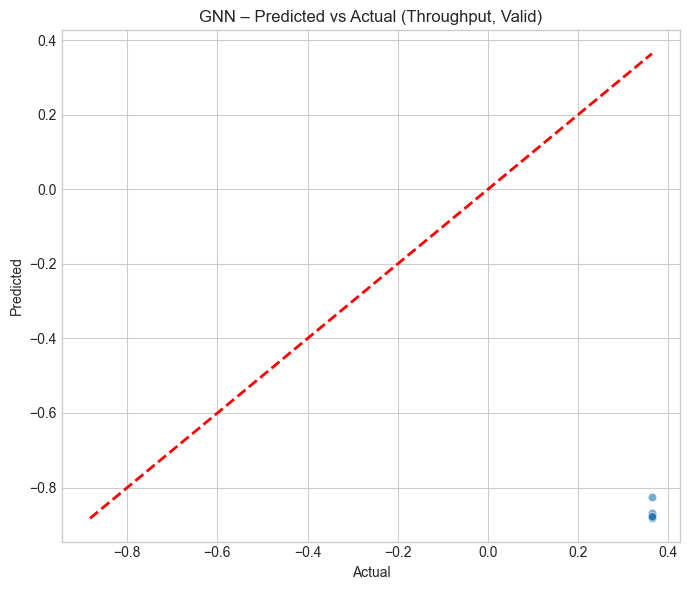

Saved → ../outputs/models/plots/gnn_Throughput_ts_valid.png


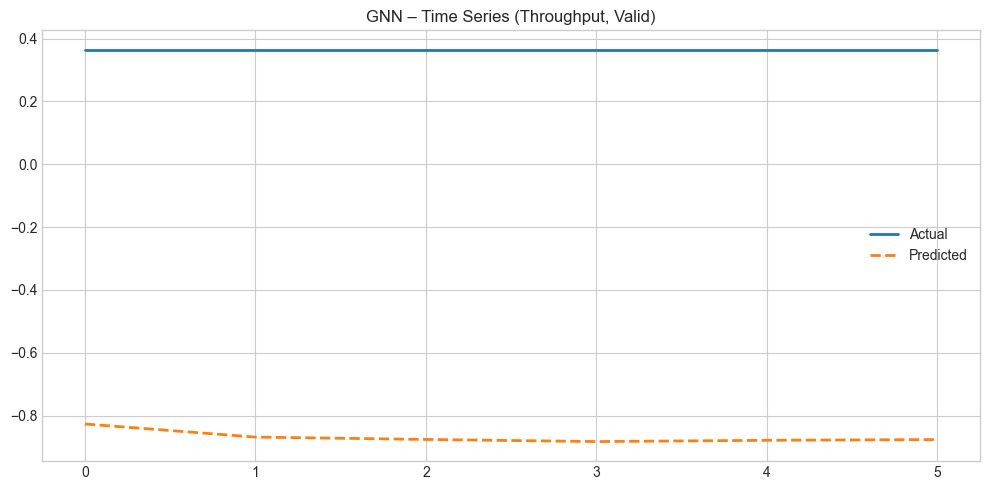

Saved → ../outputs/models/plots/gnn_Throughput_pred_test.png


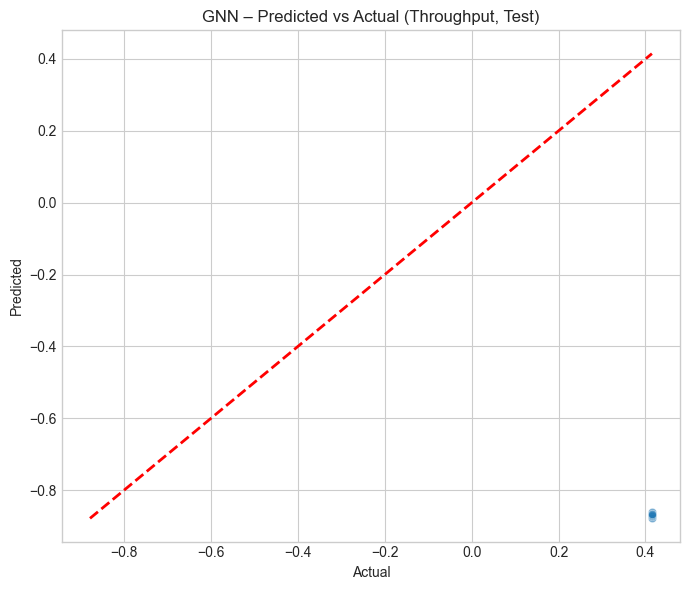

Saved → ../outputs/models/plots/gnn_Throughput_ts_test.png


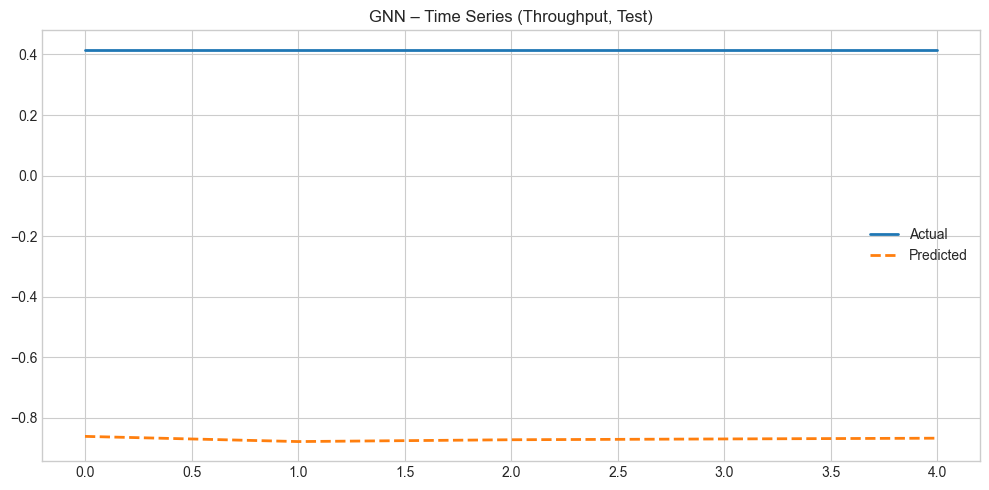


=== Generating GNN plots for Latency ===
Saved → ../outputs/models/plots/gnn_Latency_pred_valid.png


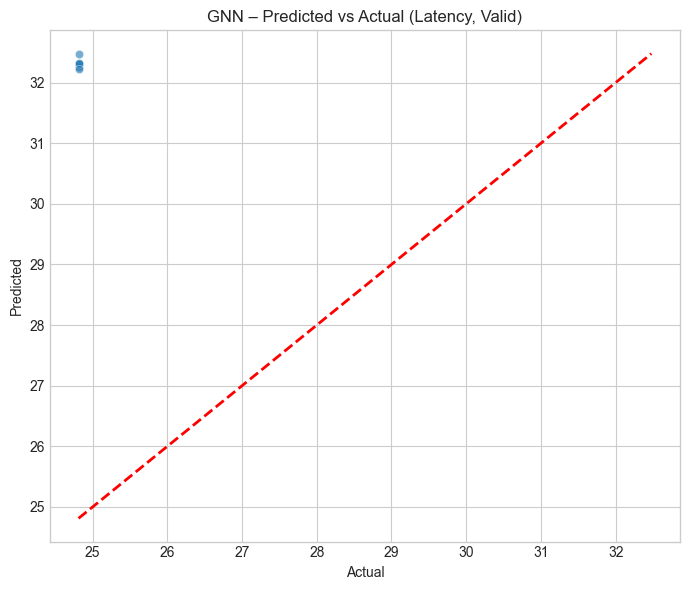

Saved → ../outputs/models/plots/gnn_Latency_ts_valid.png


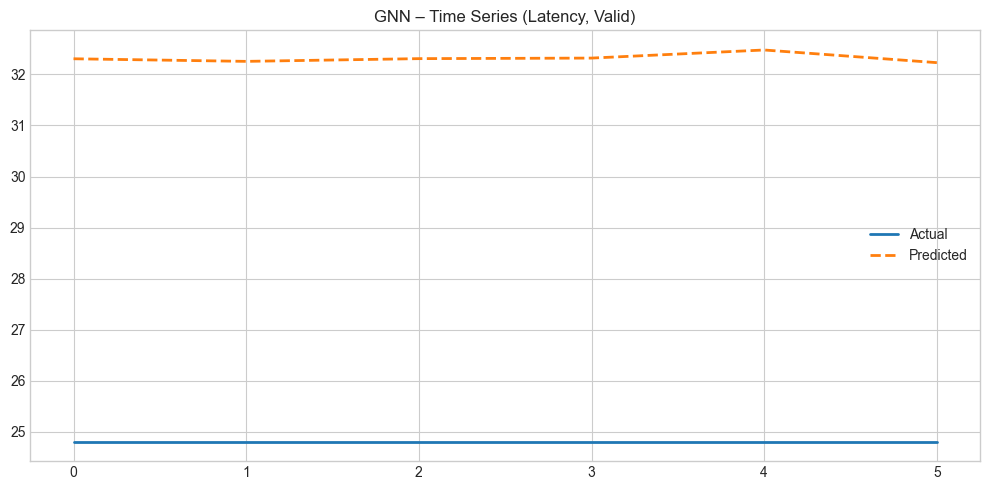

Saved → ../outputs/models/plots/gnn_Latency_pred_test.png


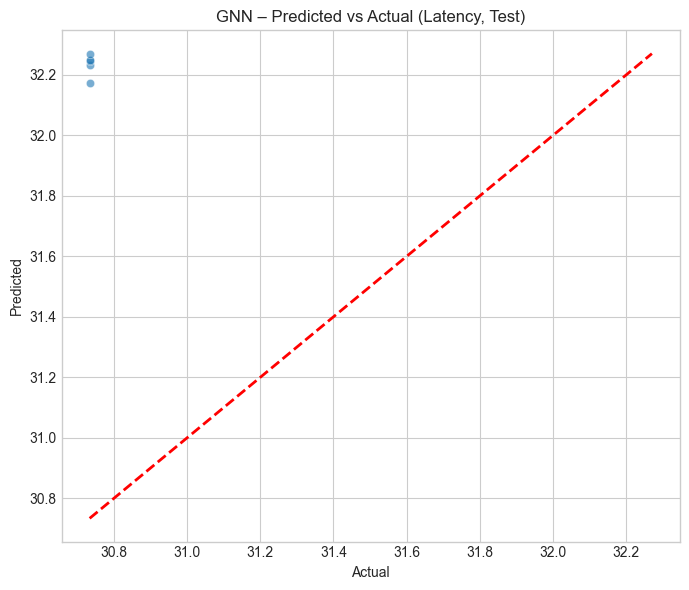

Saved → ../outputs/models/plots/gnn_Latency_ts_test.png


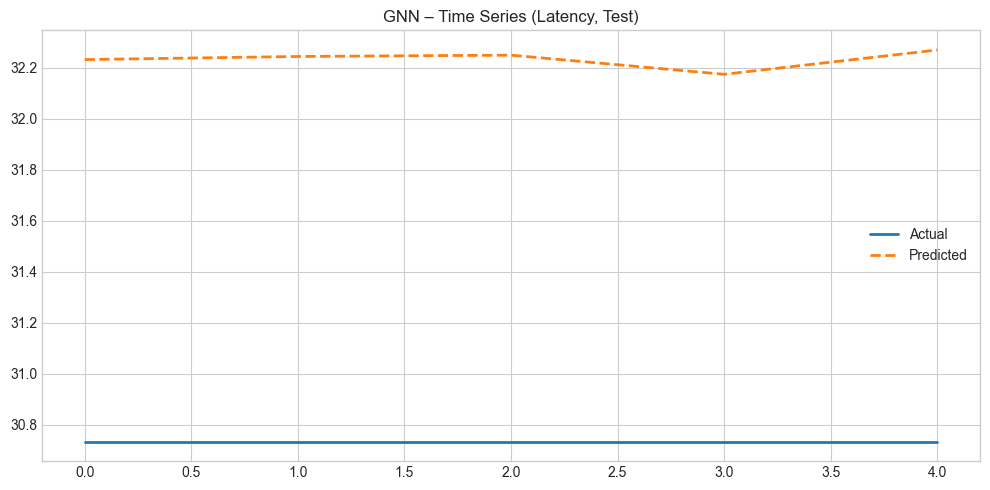


=== Generating GNN plots for Loss ===
Saved → ../outputs/models/plots/gnn_Loss_pred_valid.png


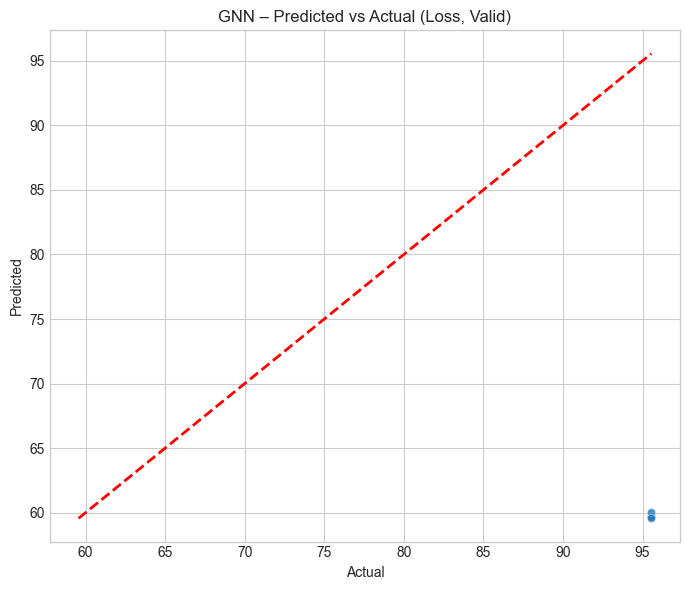

Saved → ../outputs/models/plots/gnn_Loss_ts_valid.png


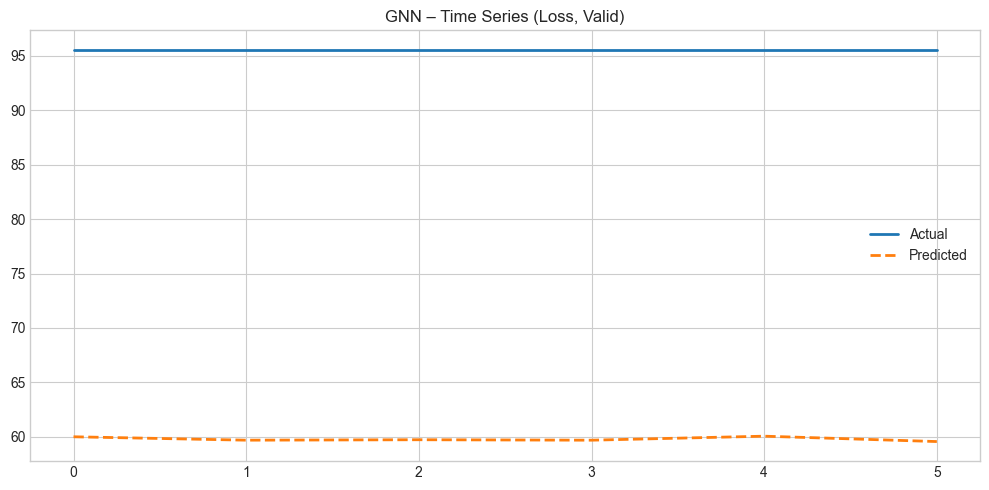

Saved → ../outputs/models/plots/gnn_Loss_pred_test.png


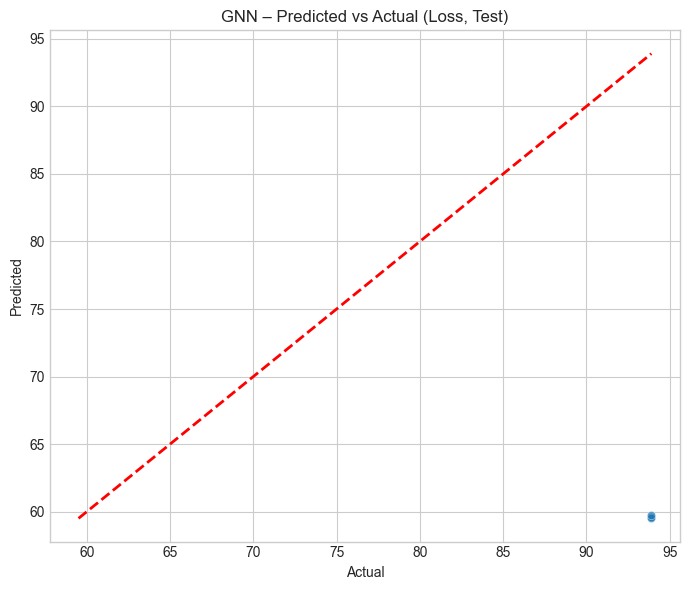

Saved → ../outputs/models/plots/gnn_Loss_ts_test.png


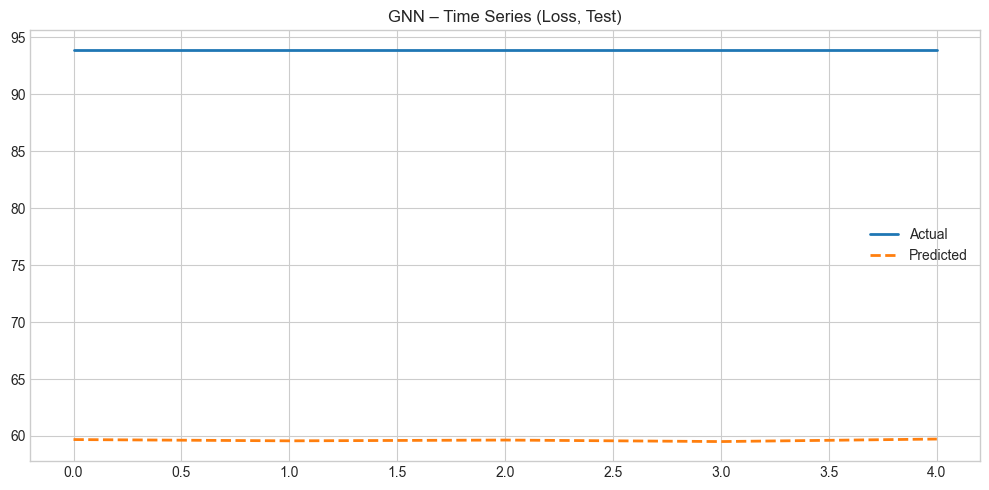


All GNN plots generated successfully!


In [13]:
generate_gnn_plots(showImage=True) 

In [ ]:
# import os
# import time
# import torch
# import numpy as np
# from torch import nn

# # ============================================================
# # Device
# # ============================================================

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # ============================================================
# # Utilities
# # ============================================================

# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)


# def model_size_bytes(model):
#     return sum(p.numel() * p.element_size() for p in model.parameters())


# def measure_latency(model, example_input, runs=200, warmup=50):
#     model.eval()
#     example_input = example_input.to(DEVICE)

#     with torch.no_grad():
#         # Warmup
#         for _ in range(warmup):
#             _ = model(example_input)

#         t0 = time.perf_counter()
#         for _ in range(runs):
#             _ = model(example_input)
#         t1 = time.perf_counter()

#     return (t1 - t0) / runs


# def estimate_energy(latency_s, assumed_power_W=5.0):
#     """
#     Approximate edge energy consumption
#     """
#     return latency_s * assumed_power_W


# # ============================================================
# # GNN Edge Evaluation
# # ============================================================

# def evaluate_gnn_edge(
#     model_path,
#     input_dim,
#     num_nodes=10,
#     assumed_power_W=5.0
# ):
#     """
#     Edge evaluation for GNN model

#     Parameters
#     ----------
#     model_path : str
#         Path to trained GNN .pt file
#     input_dim : int
#         Feature dimension per node
#     num_nodes : int
#         Number of nodes in synthetic graph
#     """

#     # -----------------------------
#     # Load model
#     # -----------------------------
#     model = torch.load(model_path, map_location=DEVICE)
#     state_dict = torch.load(model_path, map_location=DEVICE)
#     model.load_state_dict(state_dict)     # ✅ KEY LINE
#     model.to(DEVICE)
#     model.eval()

#     # -----------------------------
#     # Synthetic graph input
#     # -----------------------------
#     # Node features: (num_nodes, input_dim)
#     x = torch.randn(num_nodes, input_dim)

#     # Fully connected edge index (simple proxy)
#     edge_index = torch.combinations(
#         torch.arange(num_nodes), r=2
#     ).t()
#     edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

#     x = x.to(DEVICE)
#     edge_index = edge_index.to(DEVICE)

#     # Wrapper input for timing
#     example_input = (x, edge_index)

#     # -----------------------------
#     # Latency
#     # -----------------------------
#     def forward():
#         return model(x, edge_index)

#     # Warmup
#     with torch.no_grad():
#         for _ in range(30):
#             _ = forward()

#     runs = 200
#     t0 = time.perf_counter()
#     with torch.no_grad():
#         for _ in range(runs):
#             _ = forward()
#     t1 = time.perf_counter()

#     latency = (t1 - t0) / runs

#     # -----------------------------
#     # Model statistics
#     # -----------------------------
#     params = count_parameters(model)
#     size_bytes = model_size_bytes(model)
#     size_mb = size_bytes / (1024 ** 2)

#     energy = estimate_energy(latency, assumed_power_W)

#     peak_activation_bytes = x.numel() * x.element_size()

#     # -----------------------------
#     # Return metrics
#     # -----------------------------
#     return {
#         "Parameters": params,
#         "Model Size (Bytes)": size_bytes,
#         "Model Size (MB)": size_mb,
#         "Latency (s)": latency,
#         "Latency (ms)": latency * 1e3,
#         "Estimated Energy (J)": energy,
#         "Peak Activation Memory (Bytes)": peak_activation_bytes,
#         "Model Path": model_path,
#         "Num Nodes": num_nodes,
#         "Input Dim": input_dim,
#     }


In [37]:
def evaluate_gnn_edge(
    model_path,
    input_dim=3,          # MUST match training
    hidden_dim=32,        # MUST match training
    num_nodes=10,
    assumed_power_W=5.0
):
    import time
    import torch
    from torch import nn
    from torch_geometric.nn import GCNConv

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # --------------------------------------------------
    # GNN architecture (MATCH TRAINING EXACTLY)
    # --------------------------------------------------
    class GNNModel(nn.Module):
        def __init__(self, input_dim, hidden_dim):
            super().__init__()
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.fc = nn.Linear(hidden_dim, 1)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index)
            x = torch.relu(x)
            x = self.conv2(x, edge_index)
            x = torch.relu(x)
            x = self.fc(x)
            return x.mean(dim=0, keepdim=True)

    # --------------------------------------------------
    # Load model weights (CORRECT)
    # --------------------------------------------------
    model = GNNModel(input_dim, hidden_dim)
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    # --------------------------------------------------
    # Synthetic graph input (node-level)
    # --------------------------------------------------
    x = torch.randn(num_nodes, input_dim, device=DEVICE)

    edge_index = torch.combinations(
        torch.arange(num_nodes), r=2
    ).t()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    edge_index = edge_index.to(DEVICE)

    # --------------------------------------------------
    # Latency measurement
    # --------------------------------------------------
    with torch.no_grad():
        for _ in range(20):  # warmup
            _ = model(x, edge_index)

        runs = 200
        t0 = time.perf_counter()
        for _ in range(runs):
            _ = model(x, edge_index)
        t1 = time.perf_counter()

    latency = (t1 - t0) / runs

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------
    params = sum(p.numel() for p in model.parameters())
    size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    size_mb = size_bytes / (1024 ** 2)
    energy = latency * assumed_power_W
    peak_activation = x.numel() * x.element_size()

    return {
        "Parameters": params,
        "Model Size (Bytes)": size_bytes,
        "Model Size (MB)": size_mb,
        "Latency (s)": latency,
        "Latency (ms)": latency * 1e3,
        "Estimated Energy (J)": energy,
        "Peak Activation Memory (Bytes)": peak_activation,
        "Num Nodes": num_nodes,
        "Node Feature Dim": input_dim,
        "Hidden Dim": hidden_dim,
        "Model Path": model_path,
    }


In [35]:
metrics = evaluate_gnn_edge(
    model_path="../outputs/models/gnn_model_throughput.pt",
    input_dim=3,
    num_nodes=10
)

for k, v in metrics.items():
    print(f"{k}: {v}")


Parameters: 1217
Model Size (Bytes): 4868
Model Size (MB): 0.004642486572265625
Latency (s): 0.0022797890001675114
Latency (ms): 2.2797890001675114
Estimated Energy (J): 0.011398945000837556
Peak Activation Memory (Bytes): 120
Num Nodes: 10
Node Feature Dim: 3
Hidden Dim: 32
Model Path: ../outputs/models/gnn_model_throughput.pt
